In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [34]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"
DATA_FILE = DATA_DIR / "final_trip_data.parquet"


In [35]:
dur_dist_data = pd.read_parquet(DATA_FILE)
dur_dist_data.drop(columns=["start_station_id", "end_station_id", "start_station_name", "end_station_name", "start_lat", "start_lon","end_lat", "end_lon", "bike_id", "bike_model"], inplace=True)
dur_dist_data["start_day_of_week"] = dur_dist_data["start_date"].dt.day_name()

dur_dist_data["total_duration_minutes"] = dur_dist_data["total_duration_ms"] / 60000
dur_dist_data["duration_min_bin"] = (
    np.floor(dur_dist_data["total_duration_minutes"])
)

dur_dist_data.drop(columns=["total_duration_ms"], inplace=True)

In [36]:
dur_dist_data["duration_counts"] = (
    dur_dist_data["duration_min_bin"]
    .value_counts()
    .sort_index()
)

In [37]:
dur_dist_data_weekends = dur_dist_data[dur_dist_data["start_day_of_week"].isin(["Saturday", "Sunday"])]
dur_dist_data_weekdays = dur_dist_data[dur_dist_data["start_day_of_week"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])]

dur_dist_data_weekends.head()

,trip_id,start_date,end_date,total_duration,start_day_of_week,total_duration_minutes,duration_min_bin,duration_counts
0,145207079,2024-12-14 23:59:00,2024-12-14 23:59:00,29s,Saturday,0.486717,0.0,139199.0
1,145207080,2024-12-14 23:59:00,2024-12-15 00:26:00,27m 0s,Saturday,27.002733,27.0,169059.0
2,145207081,2024-12-14 23:59:00,2024-12-15 00:17:00,18m 16s,Saturday,18.283017,18.0,407161.0
3,145207082,2024-12-14 23:59:00,2024-12-15 00:12:00,13m 3s,Saturday,13.062717,13.0,635325.0
4,145207083,2024-12-14 23:59:00,2024-12-15 00:04:00,5m 22s,Saturday,5.369250,5.0,768267.0


In [38]:
# ---------- Counting rides by duration ----------

duration_counts_weekdays = (
    dur_dist_data_weekdays["duration_min_bin"]
    .value_counts()
    .sort_index()
)

duration_counts_weekends = (
    dur_dist_data_weekends["duration_min_bin"]
    .value_counts()
    .sort_index()
)

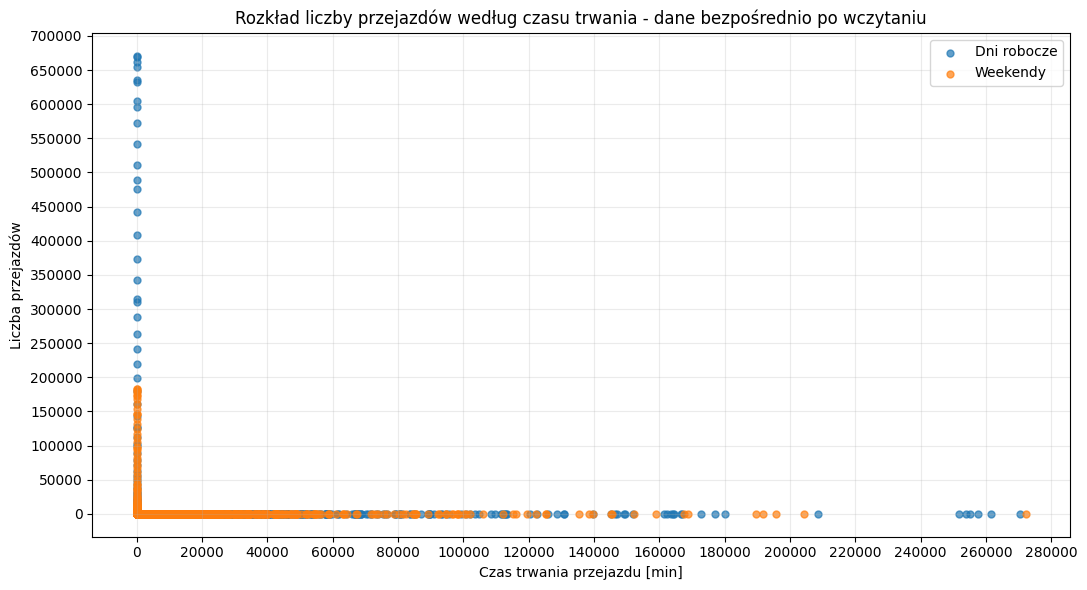

In [39]:
# ---------- Duration counts: weekdays vs weekends ----------

plt.figure(figsize=(11, 6))

plt.scatter(
    duration_counts_weekdays.index,
    duration_counts_weekdays.values,
    s=25,
    alpha=0.7,
    label="Dni robocze"
)

plt.scatter(
    duration_counts_weekends.index,
    duration_counts_weekends.values,
    s=25,
    alpha=0.7,
    label="Weekendy"
)

plt.xlabel("Czas trwania przejazdu [min]")
plt.ylabel("Liczba przejazdów")
plt.title("Rozkład liczby przejazdów według czasu trwania - dane bezpośrednio po wczytaniu")

plt.legend()
plt.grid(alpha=0.25)

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(15))
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(15))

plt.tight_layout()
plt.show()

# 1.Histograms

In [40]:
# ---------- Preparing duration data ----------

duration_weekdays = dur_dist_data_weekdays[
    dur_dist_data_weekdays["total_duration_minutes"] > 0
]["total_duration_minutes"]

duration_weekends = dur_dist_data_weekends[
    dur_dist_data_weekends["total_duration_minutes"] > 0
]["total_duration_minutes"]


# ---------- Common range ----------

min_time = min(
    duration_weekdays.min(),
    duration_weekends.min()
)

max_time = max(
    duration_weekdays.max(),
    duration_weekends.max()
)

# ---------- Logarithmic bin edges ----------

def make_log_bin_edges(min_value, max_value, a):
    bin_edges = [min_value]

    while bin_edges[-1] < max_value:
        bin_edges.append(bin_edges[-1] * a)

    return np.array(bin_edges)

# ---------- Logarithmic binning ----------

def log_binning(data, bin_edges):

    counts, edges = np.histogram(data, bins=bin_edges)

    widths = edges[1:] - edges[:-1]

    probability_density = counts / (len(data) * widths)

    bin_centers = np.sqrt(edges[:-1] * edges[1:])

    mask = probability_density > 0

    return (
        bin_centers[mask],
        probability_density[mask],
        counts[mask],
        edges
    )
# ---------- Calculating results for different a values ----------

a_values = [1.5, 1.75, 2]

results = {}

for a_value in a_values:

    bin_edges = make_log_bin_edges(
        min_time,
        max_time,
        a_value
    )

    x_weekdays, p_weekdays, n_weekdays, edges = log_binning(
        duration_weekdays,
        bin_edges
    )

    x_weekends, p_weekends, n_weekends, edges = log_binning(
        duration_weekends,
        bin_edges
    )

    results[a_value] = {
        "weekdays": {
            "x": x_weekdays,
            "p": p_weekdays,
            "n": n_weekdays
        },
        "weekends": {
            "x": x_weekends,
            "p": p_weekends,
            "n": n_weekends
        },
        "bin_edges": bin_edges
    }

    print(f"\na = {a_value}")
    print("Number of bins:", len(bin_edges) - 1)
    print("First bin edges:", bin_edges[:5])
    print("Last bin edges:", bin_edges[-5:])


a = 1.5
Number of bins: 45
First bin edges: [0.00326667 0.0049     0.00735    0.011025   0.0165375 ]
Last bin edges: [ 54180.92837261  81271.39255891 121907.08883836 182860.63325755
 274290.94988632]

a = 1.75
Number of bins: 33
First bin edges: [0.00326667 0.00571667 0.01000417 0.01750729 0.03063776]
Last bin edges: [ 36492.88788627  63862.55380098 111759.46915171 195579.0710155
 342263.37427713]

a = 2
Number of bins: 27
First bin edges: [0.00326667 0.00653333 0.01306667 0.02613333 0.05226667]
Last bin edges: [ 27402.78613333  54805.57226667 109611.14453333 219222.28906667
 438444.57813333]


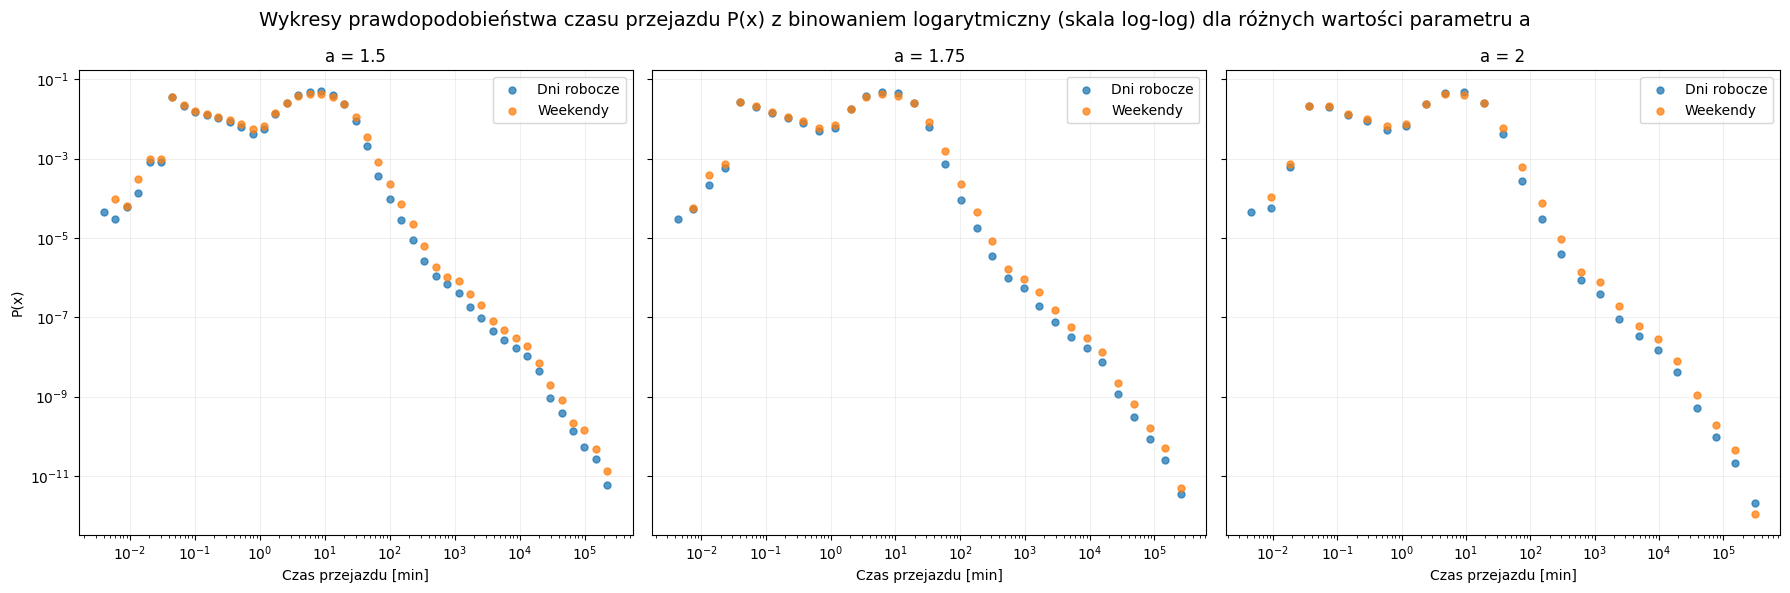

In [41]:
# ---------- Plotting logarithmic probability density ----------

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

colors = {
    "Dni robocze": "#1F77B4",
    "Weekendy": "#FF7F0E"
}

for ax, a_value in zip(axes, a_values):

    ax.scatter(
        results[a_value]["weekdays"]["x"],
        results[a_value]["weekdays"]["p"],
        s=25,
        alpha=0.75,
        color=colors["Dni robocze"],
        label="Dni robocze"
    )

    ax.scatter(
        results[a_value]["weekends"]["x"],
        results[a_value]["weekends"]["p"],
        s=25,
        alpha=0.75,
        color=colors["Weekendy"],
        label="Weekendy"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Czas przejazdu [min]")
    ax.set_title(f"a = {a_value}")

    ax.grid(True, axis="y", alpha=0.2, which="both")
    ax.grid(True, axis="x", alpha=0.2, which="major")    
    ax.legend()

axes[0].set_ylabel("P(x)")

fig.suptitle(
    "Wykresy prawdopodobieństwa czasu przejazdu P(x) z binowaniem logarytmiczny (skala log-log) dla różnych wartości parametru a",
    fontsize=14
)

plt.tight_layout()
plt.show()

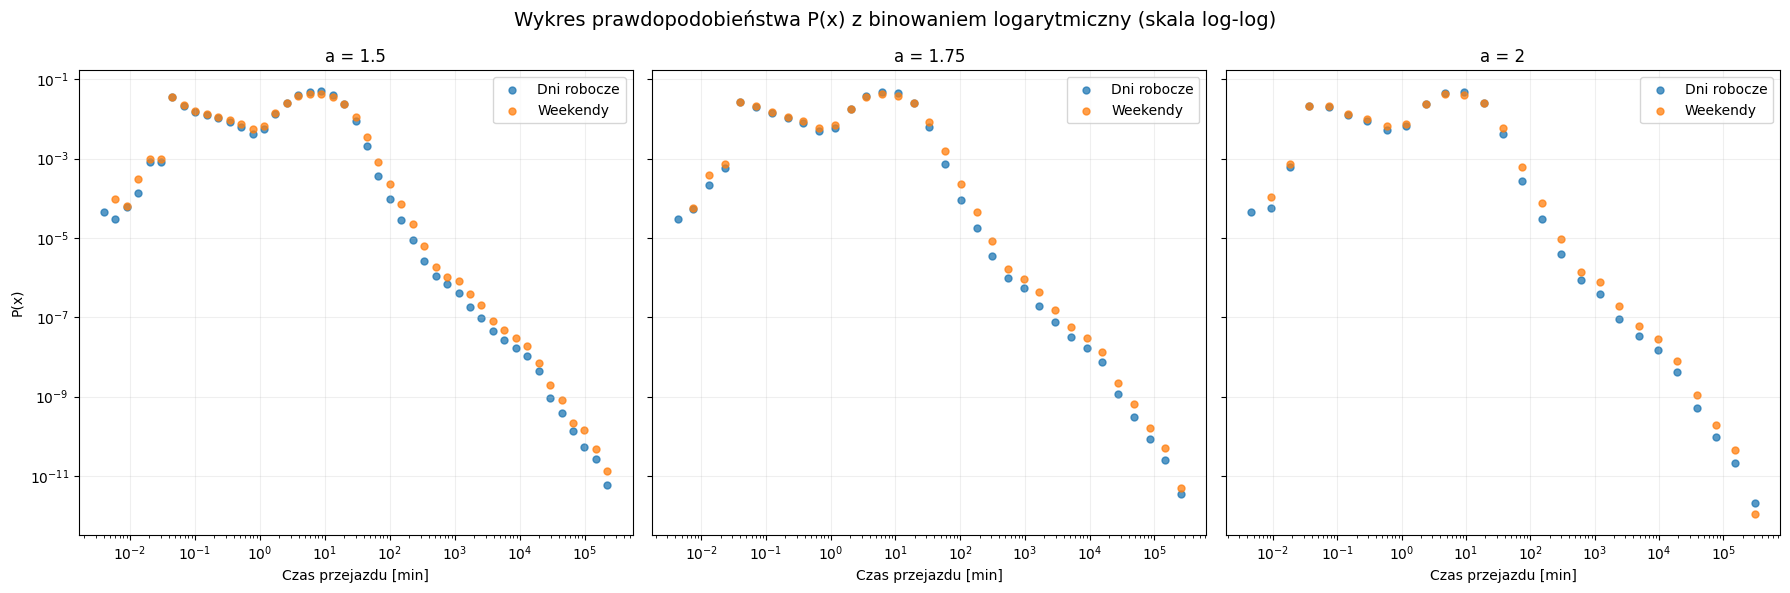

In [42]:
# ---------- Plotting logarithmic probability density ----------

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

colors = {
    "Dni robocze": "#1F77B4",
    "Weekendy": "#FF7F0E"
}

for ax, a_value in zip(axes, a_values):

    ax.scatter(
        results[a_value]["weekdays"]["x"],
        results[a_value]["weekdays"]["p"],
        s=25,
        alpha=0.75,
        color=colors["Dni robocze"],
        label="Dni robocze"
    )

    ax.scatter(
        results[a_value]["weekends"]["x"],
        results[a_value]["weekends"]["p"],
        s=25,
        alpha=0.75,
        color=colors["Weekendy"],
        label="Weekendy"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Czas przejazdu [min]")
    ax.set_title(f"a = {a_value}")

    ax.grid(True, axis="y", alpha=0.2, which="both")
    ax.grid(True, axis="x", alpha=0.2, which="major")    
    ax.legend()

axes[0].set_ylabel("P(x)")

fig.suptitle(
    "Wykres prawdopodobieństwa P(x) z binowaniem logarytmiczny (skala log-log)",
    fontsize=14
)

plt.tight_layout()
plt.show()

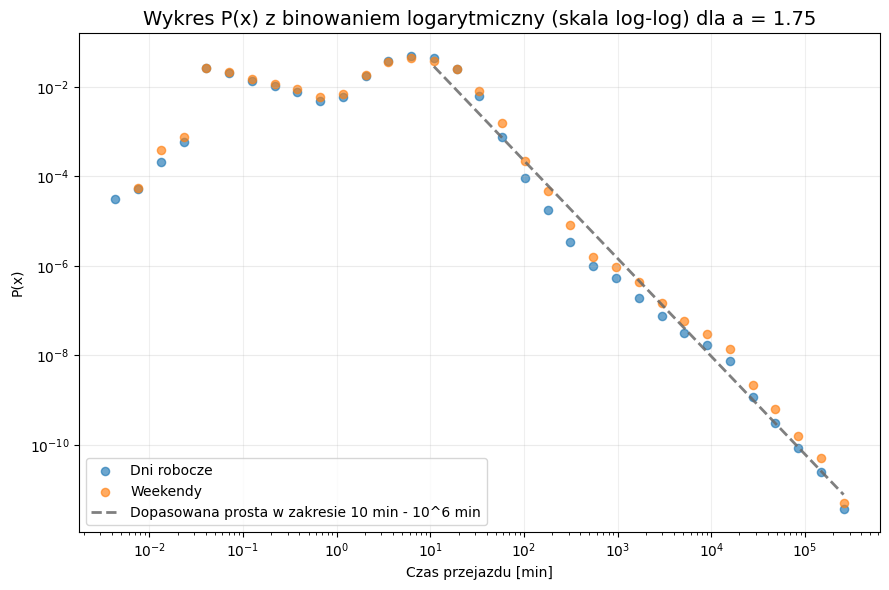

Zakres dopasowania:
x_min = 10
x_max = 1000000

Nachylenie wspólnego dopasowania: -2.188
Wyraz wolny: 0.731


In [69]:
# ---------- Common tail fit for weekdays and weekends ----------

a_value = 1.75

x_weekdays = results[a_value]["weekdays"]["x"]
y_weekdays = results[a_value]["weekdays"]["p"]

x_weekends = results[a_value]["weekends"]["x"]
y_weekends = results[a_value]["weekends"]["p"]


# ---------- Fitting range ----------

x_min = 10**1
x_max = 10**6


# ---------- Combining weekdays and weekends for one common fit ----------

x_all = np.concatenate([x_weekdays, x_weekends])
y_all = np.concatenate([y_weekdays, y_weekends])

fit_mask = (
    (x_all > 0) &
    (y_all > 0) &
    (x_all >= x_min) &
    (x_all <= x_max)
)

x_fit_data = x_all[fit_mask]
y_fit_data = y_all[fit_mask]


# ---------- Log-log fit ----------

log_x = np.log10(x_fit_data)
log_y = np.log10(y_fit_data)

slope, intercept = np.polyfit(log_x, log_y, 1)


# ---------- Fitted line ----------

x_fit = np.logspace(
    np.log10(x_fit_data.min()),
    np.log10(x_fit_data.max()),
    200
)

y_fit = 10**intercept * x_fit**slope


# ---------- Plot ----------

plt.figure(figsize= (9, 6))

colors = {
    "Dni robocze": "#1F77B4",
    "Weekendy": "#FF7F0E"
}


# all points: weekdays

plt.scatter(
    x_weekdays,
    y_weekdays,
    s=35,
    alpha=0.65,
    color=colors["Dni robocze"],
    label="Dni robocze"
)


# all points: weekends

plt.scatter(
    x_weekends,
    y_weekends,
    s=35,
    alpha=0.65,
    color=colors["Weekendy"],
    label="Weekendy"
)

# common fitted line

plt.plot(
    x_fit,
    y_fit,
    color="dimgray",
    linestyle="--",
    linewidth=2,
    alpha=0.85,
    label=f"Dopasowana prosta w zakresie 10 min - 10^6 min"
)

# ---------- Scales and labels ----------

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Czas przejazdu [min]")
plt.ylabel("P(x)")

plt.title(
    "Wykres P(x) z binowaniem logarytmiczny (skala log-log) dla a = 1.75",
    fontsize=14)

plt.grid(True, axis="y", alpha=0.25, which="both")
plt.grid(True, axis="x", alpha=0.20, which="major")

plt.legend()
plt.tight_layout()
plt.show()


# ---------- Result ----------

print("Zakres dopasowania:")
print(f"x_min = {x_min}")
print(f"x_max = {x_max}")
print()
print("Nachylenie wspólnego dopasowania:", round(slope, 3))
print("Wyraz wolny:", round(intercept, 3))